In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.transform import rowcol
from rasterio.warp import transform


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
csv_path = Path("/content/drive/MyDrive/electric-pole-analysis/reference/matched_rows_only_pole_vegetation_streetview.csv")

chmv1_path = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/chmv1_rgb3_alpha_nodata255_res060_chm.tif")
chmv2_min_path = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/chmv2_minimal_tile512_ov64.tif")
chmv2_std_path = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/chmv2_standardized_tile512_ov64.tif")


In [ ]:
RADIUS_M = 2.0
POLE_HEIGHT_FT = 30.0
POLE_HEIGHT_M = POLE_HEIGHT_FT * 0.3048


In [ ]:
df = pd.read_csv(csv_path)
print(df.shape)
df.head()


(319, 16)


,pole_id,image_name,veg_id,veg_name,comment,labeled_at,objectid,elt_id,pole_lat,pole_lng,sv_status,pano_id,sv_date,sv_lat,sv_lng,copyright
0,38.971930_-77.057118,38.971930_-77.057118.jpg,3,critical,NaN,2026-02-24T10:53:07,41451,2583,38.971930,-77.057118,OK,rVYhqRB4nhTEqNZbngf7Sg,2025-10,38.971957,-77.057194,© Google
1,38.971930_-77.060122,38.971930_-77.060122.jpg,0,clear,As the pole and the tree/vegetation is far awa...,2026-02-24T10:54:41,50925,7468,38.971930,-77.060122,OK,t-9WpFk496NIxj0mGpuIKA,2025-08,38.971592,-77.060489,© Google
2,38.971936_-77.057288,38.971936_-77.057288.jpg,0,clear,The pole is horizontally farway from the veget...,2026-02-24T11:01:20,31948,2719,38.971936,-77.057288,OK,jXNU1hWyoUzSmwDX5as9Pw,2025-10,38.971891,-77.057278,© Google
3,38.971966_-77.059086,38.971966_-77.059086.jpg,3,critical,The pole is horizontally farway from the veget...,2026-02-24T11:01:34,47735,7253,38.971966,-77.059086,OK,qIKTMQB2SAjdiJq_GlbfYw,2025-08,38.971964,-77.059175,© Google
4,38.972012_-77.065174,38.972012_-77.065174.jpg,3,critical,The pole is horizontally farway from the veget...,2026-02-24T11:01:51,63600,8318,38.972012,-77.065174,OK,Zm3YbTWPIn3d8QNjNaIvuQ,2025-08,38.972052,-77.065114,© Google


In [ ]:
def classify_manual_risk(row):
    veg_id = row["veg_id"]
    veg_name = str(row["veg_name"]).strip().lower()

    if veg_id == 0 or veg_name in {"clear", "safe"}:
        return "safe"
    if veg_id in {1, 2, 3} or veg_name in {"high", "watch", "critical", "risk"}:
        return "risk"
    return "unknown"

df["manual_risk"] = df.apply(classify_manual_risk, axis=1)
df["pole_height_m"] = POLE_HEIGHT_M


In [ ]:
with rasterio.open(chmv1_path) as src:
    chmv1 = src.read(1)
    chmv1_transform = src.transform
    chmv1_crs = src.crs

with rasterio.open(chmv2_min_path) as src:
    chmv2_min = src.read(1)
    chmv2_min_transform = src.transform
    chmv2_min_crs = src.crs

with rasterio.open(chmv2_std_path) as src:
    chmv2_std = src.read(1)
    chmv2_std_transform = src.transform
    chmv2_std_crs = src.crs


In [ ]:
xs, ys = transform(
    "EPSG:4326",
    chmv1_crs,
    df["pole_lng"].tolist(),
    df["pole_lat"].tolist(),
)

df["x_utm"] = xs
df["y_utm"] = ys


In [ ]:
def sample_point_height(arr, transform_obj, x, y):
    row, col = rowcol(transform_obj, x, y)

    if row < 0 or col < 0 or row >= arr.shape[0] or col >= arr.shape[1]:
        return np.nan

    value = arr[row, col]
    if not np.isfinite(value):
        return np.nan

    return float(value)

def point_risk(height_m, pole_height_m):
    if pd.isna(height_m):
        return "no_data"
    return "risk" if height_m >= pole_height_m else "safe"


In [ ]:
df["chmv1_point_height_m"] = [
    sample_point_height(chmv1, chmv1_transform, x, y)
    for x, y in zip(df["x_utm"], df["y_utm"])
]

df["chmv2_min_point_height_m"] = [
    sample_point_height(chmv2_min, chmv2_min_transform, x, y)
    for x, y in zip(df["x_utm"], df["y_utm"])
]

df["chmv2_std_point_height_m"] = [
    sample_point_height(chmv2_std, chmv2_std_transform, x, y)
    for x, y in zip(df["x_utm"], df["y_utm"])
]

df["chmv1_point_risk"] = df["chmv1_point_height_m"].apply(lambda h: point_risk(h, POLE_HEIGHT_M))
df["chmv2_min_point_risk"] = df["chmv2_min_point_height_m"].apply(lambda h: point_risk(h, POLE_HEIGHT_M))
df["chmv2_std_point_risk"] = df["chmv2_std_point_height_m"].apply(lambda h: point_risk(h, POLE_HEIGHT_M))


In [ ]:
def extract_buffer_stats(arr, transform_obj, x, y, radius_m, pole_height_m):
    row, col = rowcol(transform_obj, x, y)

    if row < 0 or col < 0 or row >= arr.shape[0] or col >= arr.shape[1]:
        return {"buffer_max_m": np.nan, "buffer_risk": "no_data"}

    pixel_size_x = abs(transform_obj.a)
    pixel_size_y = abs(transform_obj.e)

    row_radius = int(np.ceil(radius_m / pixel_size_y))
    col_radius = int(np.ceil(radius_m / pixel_size_x))

    r0 = max(0, row - row_radius)
    r1 = min(arr.shape[0], row + row_radius + 1)
    c0 = max(0, col - col_radius)
    c1 = min(arr.shape[1], col + col_radius + 1)

    window = arr[r0:r1, c0:c1]

    rows = np.arange(r0, r1)
    cols = np.arange(c0, c1)
    rr, cc = np.meshgrid(rows, cols, indexing="ij")

    xs = transform_obj.c + (cc + 0.5) * transform_obj.a
    ys = transform_obj.f + (rr + 0.5) * transform_obj.e

    dist = np.sqrt((xs - x) ** 2 + (ys - y) ** 2)
    inside = dist <= radius_m
    valid = inside & np.isfinite(window)

    if not valid.any():
        return {"buffer_max_m": np.nan, "buffer_risk": "no_data"}

    vals = window[valid]
    max_h = float(np.nanmax(vals))

    return {
        "buffer_max_m": max_h,
        "buffer_risk": "risk" if max_h >= pole_height_m else "safe"
    }


In [ ]:
res1 = [extract_buffer_stats(chmv1, chmv1_transform, x, y, RADIUS_M, POLE_HEIGHT_M) for x, y in zip(df["x_utm"], df["y_utm"])]
res2 = [extract_buffer_stats(chmv2_min, chmv2_min_transform, x, y, RADIUS_M, POLE_HEIGHT_M) for x, y in zip(df["x_utm"], df["y_utm"])]
res3 = [extract_buffer_stats(chmv2_std, chmv2_std_transform, x, y, RADIUS_M, POLE_HEIGHT_M) for x, y in zip(df["x_utm"], df["y_utm"])]

df["chmv1_radius_max_m"] = [r["buffer_max_m"] for r in res1]
df["chmv1_radius_risk"] = [r["buffer_risk"] for r in res1]

df["chmv2_min_radius_max_m"] = [r["buffer_max_m"] for r in res2]
df["chmv2_min_radius_risk"] = [r["buffer_risk"] for r in res2]

df["chmv2_std_radius_max_m"] = [r["buffer_max_m"] for r in res3]
df["chmv2_std_radius_risk"] = [r["buffer_risk"] for r in res3]


In [ ]:
def make_confusion_table(df_in, pred_col):
    cm = pd.crosstab(
        df_in["manual_risk"],
        df_in[pred_col],
        rownames=["Manual"],
        colnames=["Predicted"]
    )
    cm = cm.reindex(index=["risk", "safe"], columns=["risk", "safe"], fill_value=0)
    return cm

def classification_metrics(cm):
    tp = cm.loc["risk", "risk"]
    fn = cm.loc["risk", "safe"]
    fp = cm.loc["safe", "risk"]
    tn = cm.loc["safe", "safe"]

    total = tp + fn + fp + tn

    accuracy = (tp + tn) / total if total else np.nan
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan

    return {
        "TP_risk": tp,
        "FN_risk": fn,
        "FP_risk": fp,
        "TN_risk": tn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "n_used": total,
    }


In [ ]:
valid_manual = {"risk", "safe"}
valid_model = {"risk", "safe"}

def clean_eval(df_in, pred_col):
    return df_in[
        df_in["manual_risk"].isin(valid_manual) &
        df_in[pred_col].isin(valid_model)
    ].copy()


In [ ]:
configs = [
    ("CHMv1", "Point", "chmv1_point_risk"),
    ("CHMv1", "Radius 2m", "chmv1_radius_risk"),
    ("CHMv2 minimal", "Point", "chmv2_min_point_risk"),
    ("CHMv2 minimal", "Radius 2m", "chmv2_min_radius_risk"),
    ("CHMv2 standardized", "Point", "chmv2_std_point_risk"),
    ("CHMv2 standardized", "Radius 2m", "chmv2_std_radius_risk"),
]

cms = {}
metrics_rows = []

for model, method, pred_col in configs:
    eval_df = clean_eval(df, pred_col)
    cm = make_confusion_table(eval_df, pred_col)
    cms[(model, method)] = cm
    metrics_rows.append({
        "model": model,
        "method": method,
        **classification_metrics(cm)
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df


,model,method,TP_risk,FN_risk,FP_risk,TN_risk,accuracy,precision,recall,specificity,f1,n_used
0,CHMv1,Point,16,114,4,107,0.510373,0.800000,0.123077,0.963964,0.213333,241
1,CHMv1,Radius 2m,24,107,7,105,0.530864,0.774194,0.183206,0.937500,0.296296,243
2,CHMv2 minimal,Point,60,70,13,98,0.655602,0.821918,0.461538,0.882883,0.591133,241
3,CHMv2 minimal,Radius 2m,83,48,19,93,0.724280,0.813725,0.633588,0.830357,0.712446,243
4,CHMv2 standardized,Point,62,68,13,98,0.663900,0.826667,0.476923,0.882883,0.604878,241
5,CHMv2 standardized,Radius 2m,75,56,19,93,0.691358,0.797872,0.572519,0.830357,0.666667,243


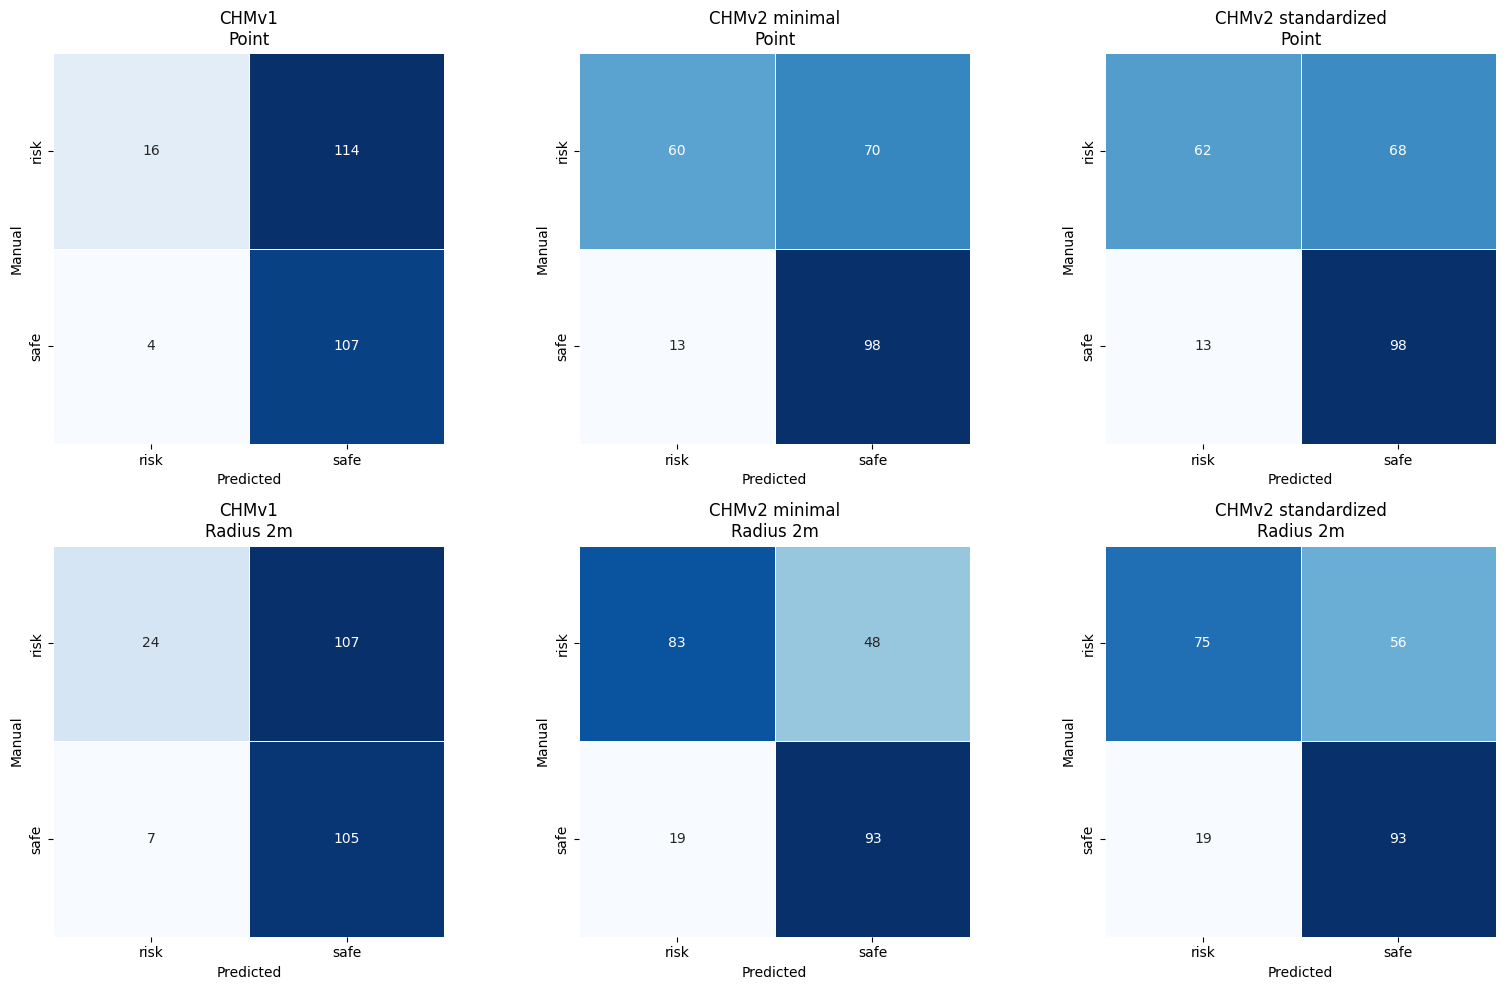

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plot_items = [
    ("CHMv1", "Point"),
    ("CHMv2 minimal", "Point"),
    ("CHMv2 standardized", "Point"),
    ("CHMv1", "Radius 2m"),
    ("CHMv2 minimal", "Radius 2m"),
    ("CHMv2 standardized", "Radius 2m"),
]

for ax, (model, method) in zip(axes.ravel(), plot_items):
    cm = cms[(model, method)]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor="white",
        ax=ax
    )
    ax.set_title(f"{model}\n{method}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Manual")

plt.tight_layout()
plt.show()


In [ ]:
metrics_pct = metrics_df.copy()

for col in ["accuracy", "precision", "recall", "specificity", "f1"]:
    metrics_pct[col] = (metrics_pct[col] * 100).round(2)

metrics_pct


,model,method,TP_risk,FN_risk,FP_risk,TN_risk,accuracy,precision,recall,specificity,f1,n_used
0,CHMv1,Point,16,114,4,107,51.04,80.00,12.31,96.40,21.33,241
1,CHMv1,Radius 2m,24,107,7,105,53.09,77.42,18.32,93.75,29.63,243
2,CHMv2 minimal,Point,60,70,13,98,65.56,82.19,46.15,88.29,59.11,241
3,CHMv2 minimal,Radius 2m,83,48,19,93,72.43,81.37,63.36,83.04,71.24,243
4,CHMv2 standardized,Point,62,68,13,98,66.39,82.67,47.69,88.29,60.49,241
5,CHMv2 standardized,Radius 2m,75,56,19,93,69.14,79.79,57.25,83.04,66.67,243


In [ ]:
pivot_metrics = metrics_pct.pivot(index="model", columns="method", values=["accuracy", "precision", "recall", "specificity", "f1"])
pivot_metrics


accuracy           precision           recall            \
method                Point Radius 2m     Point Radius 2m  Point Radius 2m   
model                                                                        
CHMv1                 51.04     53.09     80.00     77.42  12.31     18.32   
CHMv2 minimal         65.56     72.43     82.19     81.37  46.15     63.36   
CHMv2 standardized    66.39     69.14     82.67     79.79  47.69     57.25   

                   specificity               f1            
method                   Point Radius 2m  Point Radius 2m  
model                                                      
CHMv1                    96.40     93.75  21.33     29.63  
CHMv2 minimal            88.29     83.04  59.11     71.24  
CHMv2 standardized       88.29     83.04  60.49     66.67

In [ ]:
delta_rows = []

for model in metrics_df["model"].unique():
    point_row = metrics_df[(metrics_df["model"] == model) & (metrics_df["method"] == "Point")].iloc[0]
    radius_row = metrics_df[(metrics_df["model"] == model) & (metrics_df["method"] == "Radius 2m")].iloc[0]

    delta_rows.append({
        "model": model,
        "accuracy_delta": radius_row["accuracy"] - point_row["accuracy"],
        "precision_delta": radius_row["precision"] - point_row["precision"],
        "recall_delta": radius_row["recall"] - point_row["recall"],
        "specificity_delta": radius_row["specificity"] - point_row["specificity"],
        "f1_delta": radius_row["f1"] - point_row["f1"],
    })

delta_df = pd.DataFrame(delta_rows)

for col in ["accuracy_delta", "precision_delta", "recall_delta", "specificity_delta", "f1_delta"]:
    delta_df[col] = (delta_df[col] * 100).round(2)

delta_df


,model,accuracy_delta,precision_delta,recall_delta,specificity_delta,f1_delta
0,CHMv1,2.05,-2.58,6.01,-2.65,8.30
1,CHMv2 minimal,6.87,-0.82,17.20,-5.25,12.13
2,CHMv2 standardized,2.75,-2.88,9.56,-5.25,6.18


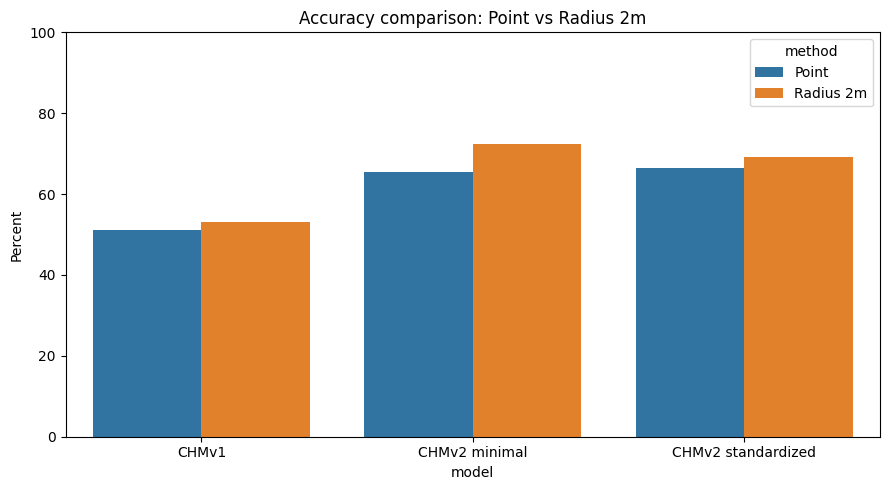

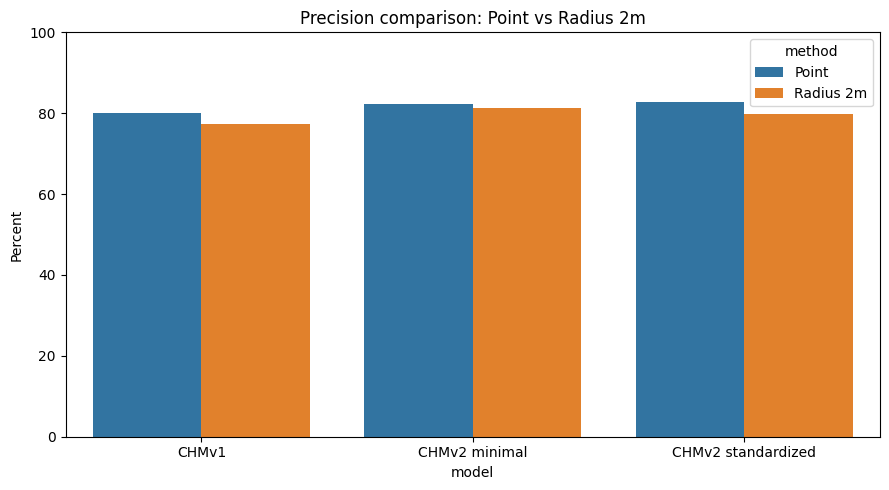

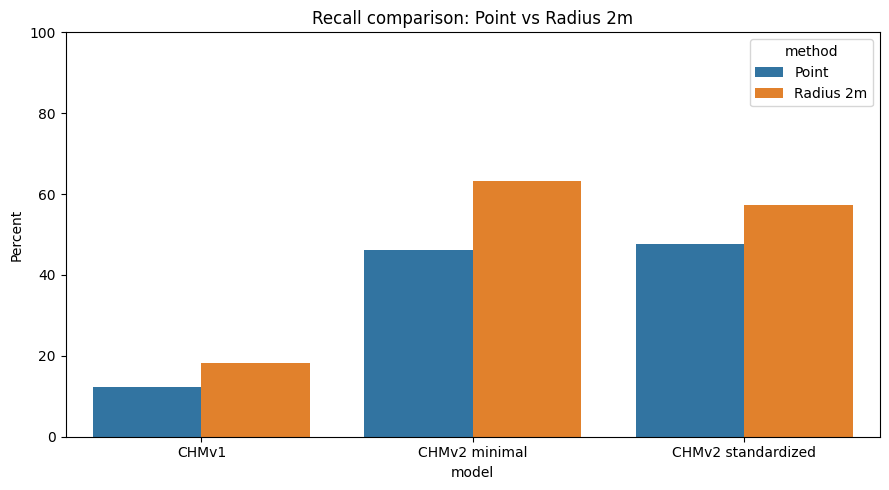

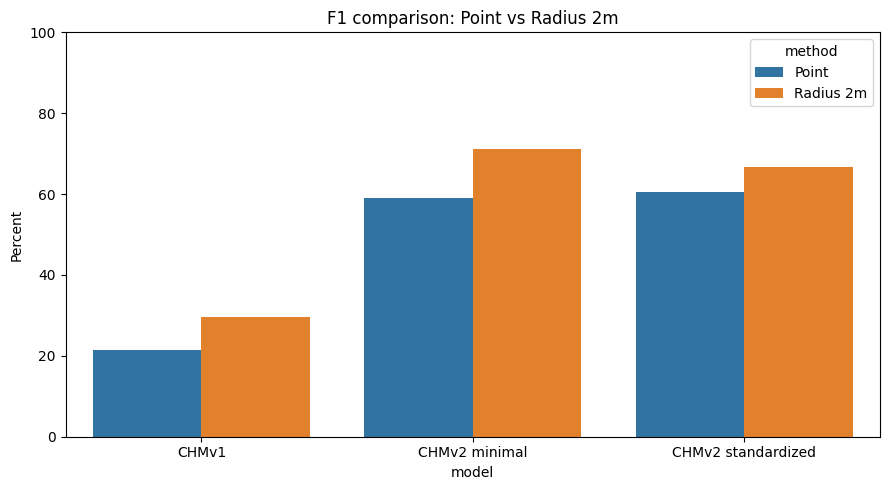

In [ ]:
for metric in ["accuracy", "precision", "recall", "f1"]:
    plt.figure(figsize=(9, 5))
    sns.barplot(data=metrics_pct, x="model", y=metric, hue="method")
    plt.title(f"{metric.capitalize()} comparison: Point vs Radius 2m")
    plt.ylabel("Percent")
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [ ]:
count_df = metrics_df[["model", "method", "TP_risk", "FN_risk", "FP_risk", "TN_risk", "n_used"]].copy()
count_df


,model,method,TP_risk,FN_risk,FP_risk,TN_risk,n_used
0,CHMv1,Point,16,114,4,107,241
1,CHMv1,Radius 2m,24,107,7,105,243
2,CHMv2 minimal,Point,60,70,13,98,241
3,CHMv2 minimal,Radius 2m,83,48,19,93,243
4,CHMv2 standardized,Point,62,68,13,98,241
5,CHMv2 standardized,Radius 2m,75,56,19,93,243


In [ ]:
best_overall = metrics_df.loc[metrics_df["f1"].idxmax(), ["model", "method", "f1", "recall", "precision"]]
best_recall = metrics_df.loc[metrics_df["recall"].idxmax(), ["model", "method", "recall"]]

print("Best overall by F1:")
print(best_overall)

print("\nBest recall for risk:")
print(best_recall)


Best overall by F1:
model        CHMv2 minimal
method           Radius 2m
f1                0.712446
recall            0.633588
precision         0.813725
Name: 3, dtype: object

Best recall for risk:
model     CHMv2 minimal
method        Radius 2m
recall         0.633588
Name: 3, dtype: object


In [ ]:
output_csv = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/point_vs_radius_metrics_comparison.csv")
metrics_pct.to_csv(output_csv, index=False)
print("Saved:", output_csv)


Saved: /content/drive/MyDrive/electric-pole-analysis/outputs/point_vs_radius_metrics_comparison.csv
